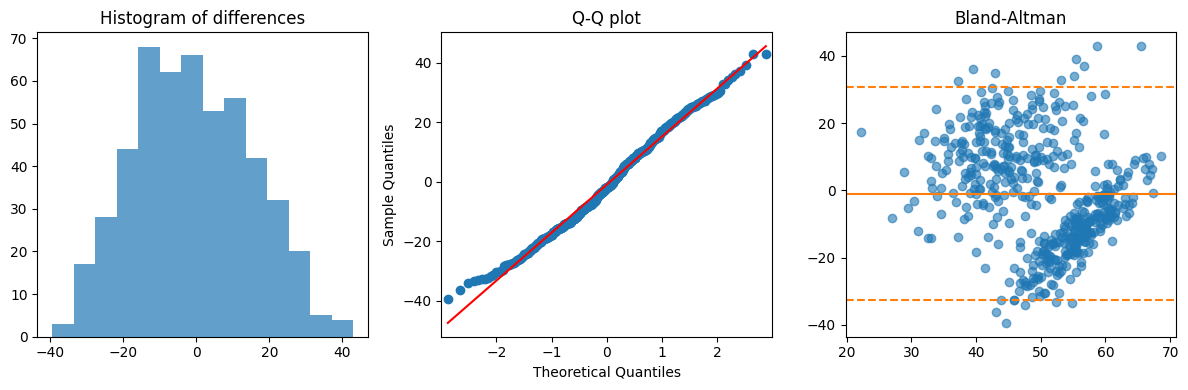

n = 500
Test used: Paired t‑test
Normality OK? True
Mean(diff) = -0.9765, SD(diff) = 16.1581
t‑stat = -1.3514
Cohen's dz = -0.0604, Hedges' g = -0.0603
P‑value = 0.17718 (Paired t‑test); significant difference at α = 0.05?
No


In [1]:
import os
from pathlib import Path
import json

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import skew

# -------------------- Parameters --------------------
INPUT = Path("input_data/data.csv")
OUTPUT = Path("/display_output/final_result.txt")
SUMMARY_OUT = Path("/display_output/final_summary.json")
PLOT_OUT = Path("/display_output/diff_diagnostics.png")
ALPHA = 0.05

# -------------------- Load data --------------------
if INPUT.is_file():
    df = pd.read_csv(INPUT)
else:
    np.random.seed(0)
    df = pd.DataFrame({
        "A": np.random.normal(0, 1, 30),
        "B": np.random.normal(0, 1, 30)
    })
    print(f"File {INPUT} not found – using synthetic data.")

# -------------------- Verify & clean --------------------
required = {"A", "B"}
if not required.issubset(df.columns):
    raise ValueError("Columns 'A' and 'B' not found in input.")
df_clean = df.loc[:, ["A", "B"]].apply(pd.to_numeric, errors="coerce").dropna()
n = len(df_clean)
if n == 0:
    result = "No"
    OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT.write_text(result)
    raise SystemExit("No usable paired observations.")
if n < 3:
    result = "No"
    OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT.write_text(result)
    raise SystemExit(f"Too few observations (n={n}).")

# -------------------- Differences --------------------
diff = df_clean["A"] - df_clean["B"]

# -------------------- Plot diagnostics --------------------
PLOT_OUT.parent.mkdir(parents=True, exist_ok=True)
plt.figure(figsize=(12, 4))

# histogram
plt.subplot(1, 3, 1)
plt.hist(diff, bins="auto", alpha=0.7, color="#1f77b4")
plt.title("Histogram of differences")

# Q‑Q plot
plt.subplot(1, 3, 2)
sm.qqplot(diff, line='s', ax=plt.gca())
plt.title("Q‑Q plot")

# Bland‑Altman
plt.subplot(1, 3, 3)
mean_ab = (df_clean["A"] + df_clean["B"]) / 2
sd_diff = diff.std(ddof=1)
mean_diff = diff.mean()
plt.scatter(mean_ab, diff, alpha=0.6)
plt.axhline(mean_diff, color='C1')
plt.axhline(mean_diff + 1.96 * sd_diff, color='C1', linestyle='--')
plt.axhline(mean_diff - 1.96 * sd_diff, color='C1', linestyle='--')
plt.title("Bland‑Altman")
plt.tight_layout()
plt.savefig(PLOT_OUT)
plt.show()

# -------------------- Normality decision --------------------
if n < 30:
    _, sh_p = stats.shapiro(diff)
    normality_ok = sh_p > ALPHA
else:
    normality_ok = True  # CLT

# -------------------- Symmetry / ties handling --------------------
n_zeros = (diff == 0).sum()


def perm_paired(x, y, n_perm=20000, seed=0):
    rng = np.random.default_rng(seed)
    d = x - y
    obs = abs(d.mean())
    signs = rng.choice([1, -1], size=(n_perm, len(d)))
    perm_means = np.abs((signs * d).mean(axis=1))
    return (np.sum(perm_means >= obs) + 1) / (n_perm + 1)


if n_zeros == n:
    p_val = 1.0
    test_used = "All-zero differences"
    test_stat = np.nan
elif n_zeros / n > 0.2:
    p_val = perm_paired(df_clean["A"].values, df_clean["B"].values)
    test_used = "Permutation test (many ties)"
    test_stat = np.nan
elif not normality_ok:
    # use Wilcoxon unless symmetry badly violated
    sk = skew(diff)
    if abs(sk) > 1.0:
        p_val = perm_paired(df_clean["A"].values, df_clean["B"].values)
        test_used = "Permutation test (asymmetric diffs)"
        test_stat = np.nan
    else:
        test_stat, p_val = stats.wilcoxon(diff, zero_method="wilcox", alternative="two-sided")
        test_used = "Wilcoxon signed‑rank test"
else:
    # paired t-test
    test_stat, p_val = stats.ttest_rel(df_clean["A"], df_clean["B"], nan_policy="raise")
    test_used = "Paired t‑test"

# -------------------- Effect sizes --------------------
sd_diff = diff.std(ddof=1)
mean_diff = diff.mean()
cohen_d_z = mean_diff / sd_diff if sd_diff > 0 else np.nan
if not np.isnan(cohen_d_z) and n > 2:
    df_corr = n - 1
    j = 1 - (3.0 / (4.0 * df_corr - 1.0))
    hedges_g = cohen_d_z * j
else:
    hedges_g = np.nan

# -------------------- Decision --------------------
significant = p_val < ALPHA
result = "Yes" if significant else "No"

# -------------------- Diagnostics prints --------------------
print(f"n = {n}")
print(f"Test used: {test_used}")
print(f"Normality OK? {normality_ok}")
print(f"Mean(diff) = {mean_diff:.4f}, SD(diff) = {sd_diff:.4f}")
if not np.isnan(test_stat):
    stat_name = "t‑stat" if "t‑test" in test_used else "W‑stat"
    print(f"{stat_name} = {test_stat:.4f}")
else:
    print("Test statistic = NA")
print(f"Cohen's dz = {cohen_d_z:.4f}, Hedges' g = {hedges_g:.4f}")

# -------------------- Second‑last: description --------------------
print(f"P‑value = {p_val:.5f} ({test_used}); significant difference at α = {ALPHA}?")

# -------------------- Last: final answer --------------------
print(result)

# -------------------- Write outputs --------------------
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
OUTPUT.write_text(result)

# -------------------- Summary JSON (with native Python types) --------------------
summary = {
    "n": int(n),
    "test": test_used,
    "p_value": float(p_val),
    "alpha": float(ALPHA),
    "significant": bool(significant),
    "cohen_d_z": None if np.isnan(cohen_d_z) else float(cohen_d_z),
    "hedges_g": None if np.isnan(hedges_g) else float(hedges_g),
    "mean_diff": float(mean_diff),
    "sd_diff": float(sd_diff)
}
SUMMARY_OUT.parent.mkdir(parents=True, exist_ok=True)
with SUMMARY_OUT.open("w") as f:
    json.dump(summary, f, indent=2)
